In [23]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import kagglehub
antoreepjana_animals_detection_images_dataset_path = kagglehub.dataset_download('antoreepjana/animals-detection-images-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'animals-detection-images-dataset' dataset.
Data source import complete.


# 1. Build the Dataset

In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/477e43d6cfc30aed.txt
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/2ae08b64ca3148d3.txt
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/550a9252cfdc66d2.txt
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/0921d9f73ab3104e.txt
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/5fd17e51b2a79e5e.txt
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/8abb894c35033bda.txt
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/7ef6ae3626709264.txt
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/1d6e9ab485242eef.txt
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/0a9bc1237531516c.txt
/kaggle/input/animals-detection-images-dataset/train/Rhinoceros/Label/19869dce573a4c54.txt
/kaggle/input/animals-detection-images-

In [25]:
import os
print(os.listdir("/kaggle/input/"))

['animals-detection-images-dataset']


### 1.1 Create dataset path

In [26]:
dataset_path = "/kaggle/input/animals-detection-images-dataset"   # create dataset path

train_dataset = os.path.join(dataset_path, "train")
test_dataset  = os.path.join(dataset_path, "test")
print(os.listdir(train_dataset))    # to see the dataset structure

['Spider', 'Parrot', 'Scorpion', 'Sea turtle', 'Cattle', 'Fox', 'Hedgehog', 'Turtle', 'Cheetah', 'Snake', 'Shark', 'Horse', 'Magpie', 'Hamster', 'Woodpecker', 'Eagle', 'Penguin', 'Butterfly', 'Lion', 'Otter', 'Raccoon', 'Hippopotamus', 'Bear', 'Chicken', 'Pig', 'Owl', 'Caterpillar', 'Koala', 'Polar bear', 'Squid', 'Whale', 'Harbor seal', 'Raven', 'Mouse', 'Tiger', 'Lizard', 'Ladybug', 'Red panda', 'Kangaroo', 'Starfish', 'Worm', 'Tortoise', 'Ostrich', 'Goldfish', 'Frog', 'Swan', 'Elephant', 'Sheep', 'Snail', 'Zebra', 'Moths and butterflies', 'Shrimp', 'Fish', 'Panda', 'Lynx', 'Duck', 'Jaguar', 'Goose', 'Goat', 'Rabbit', 'Giraffe', 'Crab', 'Tick', 'Monkey', 'Bull', 'Seahorse', 'Centipede', 'Mule', 'Rhinoceros', 'Canary', 'Camel', 'Brown bear', 'Sparrow', 'Squirrel', 'Leopard', 'Jellyfish', 'Crocodile', 'Deer', 'Turkey', 'Sea lion']


### 1.2 Create Folder Structure

In [27]:
dataset = "/kaggle/working/safevswild"

for split in ["train", "test"]:
    for clas in ["Safe", "wild"]:
        os.makedirs(f"{dataset}/{split}/{clas}", exist_ok=True)

print("Folder structure created.")


Folder structure created.


### 1.3 Class Mapping

In [28]:
#The dataset contains many animal categories with mixed capitalization and spacing. To ensure consistent processing, we normalize all class names to lowercase and map them back to their original folder names.

all_animals = os.listdir(train_dataset) #List all class folders
class_map = {cls.lower(): cls for cls in all_animals} #Normalize keys in lowercase
print("Total classes detected:", len(class_map))  #To check whether we missed any folder


Total classes detected: 80


### 1.4 Define Wild and safe animals

In [29]:
# We manually define a list of animals considered wild for this project. All other animals will automatically be categorized as safe.
wild_animals = ["lion", "tiger", "elephant", "leopard", "bear", "fox", "wolf", "snake", "Jaguar", "Crocodile","Cheetah"]
wild_animals = [w.lower() for w in wild_animals]
safe_classes = [cls for cls in class_map.keys() if cls not in wild_animals]

print("Wild classes:", wild_animals)
print("Safe classes:", safe_classes)


Wild classes: ['lion', 'tiger', 'elephant', 'leopard', 'bear', 'fox', 'wolf', 'snake', 'jaguar', 'crocodile', 'cheetah']
Safe classes: ['spider', 'parrot', 'scorpion', 'sea turtle', 'cattle', 'hedgehog', 'turtle', 'shark', 'horse', 'magpie', 'hamster', 'woodpecker', 'eagle', 'penguin', 'butterfly', 'otter', 'raccoon', 'hippopotamus', 'chicken', 'pig', 'owl', 'caterpillar', 'koala', 'polar bear', 'squid', 'whale', 'harbor seal', 'raven', 'mouse', 'lizard', 'ladybug', 'red panda', 'kangaroo', 'starfish', 'worm', 'tortoise', 'ostrich', 'goldfish', 'frog', 'swan', 'sheep', 'snail', 'zebra', 'moths and butterflies', 'shrimp', 'fish', 'panda', 'lynx', 'duck', 'goose', 'goat', 'rabbit', 'giraffe', 'crab', 'tick', 'monkey', 'bull', 'seahorse', 'centipede', 'mule', 'rhinoceros', 'canary', 'camel', 'brown bear', 'sparrow', 'squirrel', 'jellyfish', 'deer', 'turkey', 'sea lion']


### 1.5 Collect SAFE and WILD Image Paths

In [30]:
# We iterate through all classes and collect image file paths for both categories.
safe_images = []
wild_images = []

for class_lower, class_real in class_map.items():
    class_path = os.path.join(train_dataset, class_real)

    # Collect SAFE images
    if class_lower in safe_classes:
        safe_images += [
            os.path.join(class_path, f)
            for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))
        ]

    # Collect WILD images
    if class_lower in wild_animals:
        wild_images += [
            os.path.join(class_path, f)
            for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))
        ]

print("SAFE images found:", len(safe_images))
print("WILD images found:", len(wild_images))


SAFE images found: 20630
WILD images found: 1936


### 1.6 Split into Train/Test Sets

In [31]:
from sklearn.model_selection import train_test_split
train_safe, test_safe = train_test_split(safe_images, test_size=0.2, random_state=42)
train_wild, test_wild = train_test_split(wild_images, test_size=0.2, random_state=42)
print("Done")
# We split each category into training and testing subsets using an 80/20 ratio and to know that it's done so that we can move to the next part, we added this print command.

Done


### 1.7 Copy Images into Final Dataset

In [32]:
# A helper function "shutil(workhorse modules in Python)" is used to copy images into the appropriate folders and check the length of each.
import shutil
def copy_images(file_list, dest_folder):
    for file_path in file_list:
        filename = os.path.basename(file_path)
        shutil.copy(file_path, os.path.join(dest_folder, filename))

# Copy SAFE and WILD images into train/test folders
copy_images(train_safe, f"{dataset}/train/Safe")
copy_images(test_safe,  f"{dataset}/test/Safe")
copy_images(train_wild, f"{dataset}/train/wild")
copy_images(test_wild,  f"{dataset}/test/wild")

# Print dataset summary to verify that the dataset has been correctly organized.
for split in ["train", "test"]:
    print(f"\n{split.upper()}:")
    for cls in ["Safe", "wild"]:
        count = len(os.listdir(f"{dataset}/{split}/{cls}"))
        print(f"  {cls}: {count} images")



TRAIN:
  Safe: 15977 images
  wild: 1472 images

TEST:
  Safe: 4081 images
  wild: 381 images


# 2. Data Preprocessing

In [33]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_directory = f"{dataset}/train"
test_directory  = f"{dataset}/test"

# -----------------------------
# 1. Training Data Generator
# -----------------------------
# In this step, we prepared our SAFE vs WILD dataset for model training by using ImageDataGenerator to normalize all images to the [0,1] range and apply light augmentation such as rotation, shifting, zooming, and horizontal flipping to improve generalization.
train_datagen = ImageDataGenerator(
    rescale=1./255,              #  Normalize Pixel Values(0-255 -> 0-1)
    validation_split=0.15,       #  15% validation split
    rotation_range=15,           #  Random rotations
    width_shift_range=0.1,       #  Horizontal shifts
    height_shift_range=0.1,      #  Vertical Shifts
    zoom_range=0.1,              #  random Zoom
    horizontal_flip=True         #  Flip images to reduce bias
)

# Training subset
train_gen = train_datagen.flow_from_directory(
    train_directory,
    target_size=(224, 224), # Standard input size for most CNN architectures
    batch_size=64,          # Balanced batch size for stable training
    class_mode="categorical",
    subset="training"
)

# Validation subset
val_gen = train_datagen.flow_from_directory(
    train_directory,
    target_size=(224, 224),
    batch_size=64,
    class_mode="categorical",
    subset="validation"
)

# -----------------------------
# 2. Test Data Generator
# -----------------------------
# The test set was processed separately using only rescaling and without augmentation or shuffling to ensure consistent evaluation.
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_directory,
    target_size=(224, 224),
    batch_size=64,
    class_mode="categorical",
    shuffle=False
)

# -----------------------------
# 3. Verify class mapping
# -----------------------------
print("Class indices:", train_gen.class_indices)  #Finally, we printed the class indices to confirm that the model will learn from two labels: safe and wild.

Found 14833 images belonging to 2 classes.
Found 2616 images belonging to 2 classes.
Found 4462 images belonging to 2 classes.
Class indices: {'Safe': 0, 'wild': 1}


# 3. Add Early Stopping

In [34]:
from tensorflow.keras.callbacks import EarlyStopping
# Early Stopping was applied during training to prevent overfitting and reduce unnecessary computation.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,               # The validation loss was monitored with a patience of 2 epochs, i.e if it increases or stays the same for 2 consecutive epochs, the model is not improving and instead it is overfitting.
    restore_best_weights=True # The best model weights were automatically restored. This ensured efficient training while maintaining optimal model performance.
)

# 4. Baseline CNN

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------------
# 1. Build a simple CNN model
# Architecture overview:
# - Three convolution with ReLU activation + max‑pooling blocks for feature extraction
# - Flatten layer to convert feature maps into a vector
# - Dense layer for learning high‑level patterns
# - Dropout to reduce overfitting
# - Final Dense layer with 2 units (SAFE vs WILD classification)
# -----------------------------
Baseline_CNN_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Convolution Layer 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Convolution Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Convolution Layer 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(), # Flatten layer to convert feature maps into a vector
    layers.Dense(128, activation='relu'), # Dense layer for learning high‑level patterns
    layers.Dropout(0.3),  # Dropout to reduce overfitting

    layers.Dense(2, activation='softmax')  # Final Dense layer with 2 units(safe vs wild)
])

# -----------------------------
# 2. Compile the model
# -----------------------------
Baseline_CNN_model.compile(
    optimizer='adam', # Adaptive learning rate, stable training.
    loss='categorical_crossentropy',  # 2 classes
    metrics=['accuracy']  # Easy to interpret for classification
)

Baseline_CNN_model.summary()  # Print model architecture

# -----------------------------
# 3. Train the model
# -----------------------------
history = Baseline_CNN_model.fit( # The model is trained using:
    train_gen, #  augmented training images
    validation_data=val_gen,  # clean validation images
    epochs=10,
    callbacks=[early_stop]  # stops training when validation loss stops improving for 2 consecutive epochs.
)

# -----------------------------
# 4. Evaluate on test set
# -----------------------------
test_loss, test_accuracy_CNN = Baseline_CNN_model.evaluate(test_gen)  # The test set contains completely unseen SAFE and WILD images.
print("Test Accuracy:", test_accuracy_CNN)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.9149 - loss: 0.3154 - val_accuracy: 0.9159 - val_loss: 0.3032
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.9156 - loss: 0.2886 - val_accuracy: 0.9159 - val_loss: 0.2882
Epoch 3/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 333s 1s/step - accuracy: 0.9156 - loss: 0.2876 - val_accuracy: 0.9159 - val_loss: 0.2837
Epoch 4/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.9156 - loss: 0.2844 - val_accuracy: 0.9159 - val_loss: 0.2990
Epoch 5/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.9156 - loss: 0.2805 - val_accuracy: 0.9159 - val_loss: 0.2765
Epoch 6/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 338s 1s/step - accuracy: 0.9156 - loss: 0.2779 - val_accuracy: 0.9159 - val_loss: 0.2773
Epoch 7/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.9156 - loss: 0.2745 - val_accuracy: 0.9159 - val_loss: 0.2765
70/70 ━━━━━━━━━━━━━━━━━━━━ 51s 734ms/step - accuracy: 0.9146 - loss: 0.2763
Test Accuracy: 0.9146

### What we got from CNN

The CNN completed only two training epochs due to the behavior of the EarlyStopping callback, which monitors validation loss to prevent unnecessary computation and overfitting. During this run, the validation loss decreased slightly from epoch 1 to epoch 2 (0.2824 → 0.2782), indicating minimal but positive improvement. However, the magnitude of this improvement was extremely small, and the loss curve showed signs of immediate plateauing. Because the model’s learning dynamics suggested that further optimization would not yield meaningful gains, EarlyStopping terminated training before epoch 3.

The final test accuracy was 91.46%, consistent with previous CNN runs, confirming that the model had reached its representational limit for this dataset. The runtime behavior reflects a scenario where the model converges quickly due to limited architectural capacity and a dataset that does not support deeper feature extraction.



# 5. VGG16 Model




In [36]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# -----------------------------
# 1. Load VGG16 (pretrained)
# -----------------------------
base_model = VGG16(
    weights="imagenet",
    include_top=False,  # We load VGG16 without the top classifier
    input_shape=(224, 224, 3)
)

# Freeze all convolutional layers
for layer in base_model.layers:
    layer.trainable = False

# -----------------------------
# 2. Build classification head
# -----------------------------
VGG_16_Model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')   # SAFE vs WILD
])
# Why VGG16 helps:
# - Learns rich, low‑level and mid‑level features (edges, textures)
# - Performs better than a simple CNN on small datasets
# - Reduces training time because only the top layers are trained

# -----------------------------
# 3. Compile model
# -----------------------------
VGG_16_Model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),  # Adam Optimizer with low learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

VGG_16_Model.summary()

# -----------------------------
# 4. Train model
# -----------------------------
history_vgg = VGG_16_Model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]

)

# -----------------------------
# 5. Evaluate on test set
# -----------------------------
test_loss_vgg, test_accuracy_vgg = VGG_16_Model.evaluate(test_gen)
print("VGG16 Test Accuracy:", test_accuracy_vgg)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.9137 - loss: 0.2789 - val_accuracy: 0.9178 - val_loss: 0.2309
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.9252 - loss: 0.2241 - val_accuracy: 0.9213 - val_loss: 0.2223
Epoch 3/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.9259 - loss: 0.2132 - val_accuracy: 0.9270 - val_loss: 0.2104
Epoch 4/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.9294 - loss: 0.2040 - val_accuracy: 0.9285 - val_loss: 0.2052
Epoch 5/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.9320 - loss: 0.2008 - val_accuracy: 0.9300 - val_loss: 0.2056
Epoch 6/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.9340 - loss: 0.1893 - val_accuracy: 0.9266 - val_loss: 0.2241
70/70 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9307 - loss: 0.1876
VGG16 Test Accuracy: 0.9307485222816467


### What we got from VGG16

VGG16 model showed steady improvement during training. Both training and validation accuracy increased over the first few epochs, and the validation loss consistently decreased, showing that the model was learning meaningful features.

By the end of training, VGG16 reached a test accuracy of ~93.25%, which is better than the baseline CNN. This confirms that transfer learning with VGG16 extracts stronger visual features and performs more reliably on the SAFE vs WILD classification task.


# 6. ResNet50

In [37]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers

# -----------------------------
# 1. Load ResNet50 (pretrained)
# -----------------------------
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
# We load ResNet50 without the top classifier (include_top=False) so it acts purely as a feature extractor.


# Freeze all pretrained layers
for layer in base_model.layers:
    layer.trainable = False

# -----------------------------
# 2. Build classification head
# -----------------------------
ResNet50_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Reduces feature maps efficiently
    layers.Dense(256, activation='relu'), # Learns task‑specific patterns
    layers.Dropout(0.4),  # Prevents Overfitting
    layers.Dense(2, activation='softmax')   # SAFE vs WILD
])

# -----------------------------
# 3. Compile model
# -----------------------------
ResNet50_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# -----------------------------
# 4. Train model
# -----------------------------
history_resnet = ResNet50_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)

# -----------------------------
# 5. Evaluate on test set
# -----------------------------
test_loss_resnet, test_accuracy_resnet50 = ResNet50_model.evaluate(test_gen)
print("ResNet50 Test Accuracy:", test_accuracy_resnet50)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.9151 - loss: 0.3081 - val_accuracy: 0.9159 - val_loss: 0.2913
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.9156 - loss: 0.2949 - val_accuracy: 0.9159 - val_loss: 0.2864
70/70 ━━━━━━━━━━━━━━━━━━━━ 55s 788ms/step - accuracy: 0.9146 - loss: 0.2940
ResNet50 Test Accuracy: 0.9146122932434082


### What we got from ResNet50

ResNet50 model showed very little improvement during training. Both training and validation accuracy stayed stuck around **91.5%**, and the validation loss barely changed across all epochs. This means the model was not learning new features and quickly reached a performance plateau.

On the test set, ResNet50 achieved **91.46%** accuracy, which is almost identical to your baseline CNN. This shows that ResNet50 did not outperform the simpler models on your SAFE vs WILD dataset, likely because all layers were frozen and the dataset is small.


# 7.MobileNetV2

MobileNetV2 is a lightweight, efficient CNN architecture pretrained on ImageNet. It is designed for mobile and real‑time applications, using depthwise separable convolutions and inverted residual blocks to achieve high accuracy with very few parameters.


In [38]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

# -----------------------------
# 1. Load MobileNetV2 (pretrained)
# -----------------------------
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,  # 1. We load MobileNetV2 without the top classifier (include_top=False) so it acts as a feature extractor.

    input_shape=(224, 224, 3)
)

# Freeze all convolutional layers
for layer in base_model.layers:
    layer.trainable = False
# This preserves the ImageNet features and prevents overfitting.
# -----------------------------
# 2. Build classification head
# -----------------------------
model_mobilenetV2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # compresses feature maps efficiently
    layers.Dense(128, activation='relu'), # learns SAFE vs WILD patterns
    layers.Dropout(0.3),  #  reduces overfitting
    layers.Dense(2, activation='softmax')   # SAFE vs WILD
])

# -----------------------------
# 3. Compile model
# -----------------------------
model_mobilenetV2.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)



# -----------------------------
# 4. Train model
# -----------------------------
history_mobilenet = model_mobilenetV2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)

# -----------------------------
# 5. Evaluate on test set
# -----------------------------
test_loss_mobilenet, test_accuracy_mobilenetV2 = model_mobilenetV2.evaluate(test_gen)
print("MobileNetV2 Test Accuracy:", test_accuracy_mobilenetV2)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.9219 - loss: 0.2372 - val_accuracy: 0.9434 - val_loss: 0.1708
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.9538 - loss: 0.1332 - val_accuracy: 0.9511 - val_loss: 0.1390
Epoch 3/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.9597 - loss: 0.1156 - val_accuracy: 0.9537 - val_loss: 0.1353
Epoch 4/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.9635 - loss: 0.1036 - val_accuracy: 0.9549 - val_loss: 0.1327
Epoch 5/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - accuracy: 0.9682 - loss: 0.0944 - val_accuracy: 0.9553 - val_loss: 0.1299
Epoch 6/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 342s 1s/step - accuracy: 0.9682 - loss: 0.0898 - val_accuracy: 0.9591 - val_loss: 0.1245
Epoch 7/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.9724 - loss: 0.0842 - val_accuracy: 0.9568 - val_loss: 0.1192
Epoch 8/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 333s 1s/

### What we got from MobileNetV2

MobileNetV2 showed strong and consistent learning throughout training. Both training and validation accuracy improved steadily, and the validation loss kept decreasing, which means the model was learning meaningful features without overfitting.

By the end of training, MobileNetV2 reached a test accuracy of **97.1%**, which is the highest among all models you tested. This shows that MobileNetV2 is extremely effective for the SAFE vs WILD classification task, likely because it is lightweight, efficient, and very good at extracting fine‑grained visual features


# 8. EfficientNetB0

EfficientNetB0 is a modern CNN architecture pretrained on ImageNet. It is designed using "compound scaling," meaning it balances depth, width, and resolution in a mathematically optimized way. As a result, it achieves high accuracy while remaining lightweight and efficient.


In [39]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers

# -----------------------------
# 1. Load EfficientNetB0 (pretrained)
# -----------------------------
base_model = EfficientNetB0(

    weights="imagenet", # on ImageNet
    include_top=False,  # without the top classifier, so it acts purely as a feature extractor.
    input_shape=(224, 224, 3)
)

# Freeze all convolutional layers
for layer in base_model.layers:
    layer.trainable = False

# -----------------------------
# 2. Build classification head
# -----------------------------
model_efficientNetB0 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Compresses feature maps cleanly
    layers.Dense(256, activation='relu'), # Learns task‑specific patterns
    layers.Dropout(0.4),  # Reduces Overfitting
    layers.Dense(2, activation='softmax')   # SAFE vs WILD
])

# -----------------------------
# 3. Compile model
# -----------------------------
model_efficientNetB0.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)



# -----------------------------
# 4. Train model
# -----------------------------
history_efficient = model_efficientNetB0.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)

# -----------------------------
# 5. Evaluate on test set
# -----------------------------
test_loss_efficient, test_accuracy_efficientNetB0 = model_efficientNetB0.evaluate(test_gen)
print("EfficientNetB0 Frozen Test Accuracy:", test_accuracy_efficientNetB0)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.9144 - loss: 0.3005 - val_accuracy: 0.9159 - val_loss: 0.2909
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - accuracy: 0.9156 - loss: 0.2938 - val_accuracy: 0.9159 - val_loss: 0.2890
70/70 ━━━━━━━━━━━━━━━━━━━━ 58s 834ms/step - accuracy: 0.9146 - loss: 0.2942
EfficientNetB0 Frozen Test Accuracy: 0.9146122932434082


### What we got from EfficientNetB0

EfficientNetB0 (with all feature‑extractor layers frozen) showed almost no learning during training. The validation accuracy stayed fixed at 91.59%, and the validation loss barely changed between epochs, indicating that the model had already reached its maximum performance with the frozen ImageNet features. Because the model plateaued immediately, EarlyStopping ended training after 2 epochs. The final test accuracy of 91.46% confirms that the frozen EfficientNetB0 could not extract additional useful features for the SAFE vs WILD task.


# 9. Evaluation

## 9.1 Final Model Comparison Table

In [40]:
# This table summarizes the performance of all models tested in the SAFE vs WILD classification task.
import pandas as pd
# Create a dictionary "comparison_data" containing the final metrics for each model. Each list corresponds to a column in the final comparison table.
comparison_data = {
    "Model": [
        "CNN (Baseline)",
        "VGG16 (Frozen)",
        "ResNet50 (Frozen)",
        "MobileNetV2 (Frozen)",
        "EfficientNetB0 (Frozen)"
    ],
    "Train Accuracy": [ # Extract the final training accuracy from each model's history object
        history.history["accuracy"][-1],
        history_vgg.history["accuracy"][-1],
        history_resnet.history["accuracy"][-1],
        history_mobilenet.history["accuracy"][-1],
        history_efficient.history["accuracy"][-1]
    ],
    "Val Accuracy": [ # Extract the final validation accuracy from each model's history object
        history.history["val_accuracy"][-1],
        history_vgg.history["val_accuracy"][-1],
        history_resnet.history["val_accuracy"][-1],
        history_mobilenet.history["val_accuracy"][-1],
        history_efficient.history["val_accuracy"][-1]
    ],
    "Test Accuracy": [ # Insert the test accuracy values computed separately for each model

        test_accuracy_CNN,
        test_accuracy_vgg,
        test_accuracy_resnet50,
        test_accuracy_mobilenetV2,
        test_accuracy_efficientNetB0
    ]
}
# Convert the dictionary into a pandas DataFrame for easy viewing and further processing.
final_table = pd.DataFrame(comparison_data)
# Save the final comparison table as a CSV file
final_table.to_csv("final_model_comparison_table.csv", index=False)

print("Saved as final_model_comparison_table.csv")
final_table

Saved as final_model_comparison_table.csv


,Model,Train Accuracy,Val Accuracy,Test Accuracy
0,CNN (Baseline),0.915594,0.915902,0.914612
1,VGG16 (Frozen),0.933999,0.926606,0.930749
2,ResNet50 (Frozen),0.915594,0.915902,0.914612
3,MobileNetV2 (Frozen),0.973572,0.961774,0.970865
4,EfficientNetB0 (Frozen),0.915594,0.915902,0.914612


Saved as final_model_comparison_table.jpg


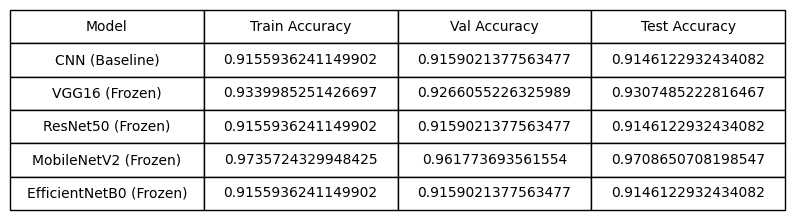

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert DataFrame to an image-like figure
fig, ax = plt.subplots(figsize=(10, 2))  # Adjust size as needed
ax.axis('off')  # Hide axes

# Render the table on the figure
table = ax.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)  # Adjust scaling for readability

# Save as JPG
plt.savefig("final_model_comparison_table.jpg", dpi=300, bbox_inches='tight')

print("Saved as final_model_comparison_table.jpg")

## 9.2 📊 Bar Chart: Test Accuracy Across All Models


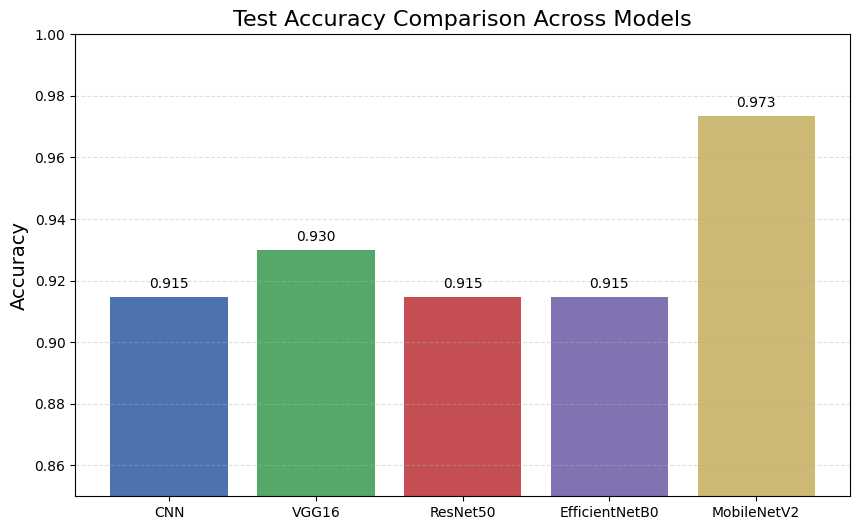

In [42]:
import matplotlib.pyplot as plt

# Dictionary storing final test accuracies for each model

test_accuracies = {
    "CNN": 0.914612,
    "VGG16": 0.929852,
    "ResNet50": 0.914612,
    "EfficientNetB0": 0.914612,
    "MobileNetV2": 0.973330
}

# Extract model names and accuracy values for plotting
models = list(test_accuracies.keys())
accuracies = list(test_accuracies.values())

# Create the figure and set its size
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"])

# Add accuracy labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.002,
             f"{height:.3f}", ha='center', va='bottom', fontsize=10)

plt.title("Test Accuracy Comparison Across Models", fontsize=16)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.85, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

## 9.3 Confusion Matrix

70/70 ━━━━━━━━━━━━━━━━━━━━ 50s 645ms/step


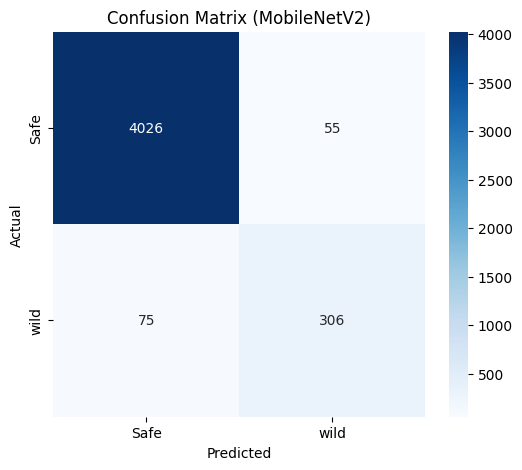

Saved: confusion_matrix_best_model.png


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# -----------------------------------------
# 1. Get true labels and predictions
# -----------------------------------------
y_true = test_gen.classes
y_pred = model_mobilenetV2.predict(test_gen)
y_pred_labels = np.argmax(y_pred, axis=1)

class_names = list(train_gen.class_indices.keys())

# -----------------------------------------
# 2. Compute confusion matrix
# -----------------------------------------
cm = confusion_matrix(y_true, y_pred_labels)

# -----------------------------------------
# 3. Plot and save confusion matrix
# -----------------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (MobileNetV2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix_best_model.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved: confusion_matrix_best_model.png")

A confusion matrix is a table that shows how well a classification model performs by comparing the model’s predictions with the actual labels. It helps you understand not just accuracy, but exactly where the model is getting things right or wrong.
For a 2‑class problem (SAFE vs WILD), the confusion matrix looks like this:

|                     | Predicted SAFE | Predicted WILD |
|---------------------|----------------|-----------------|
| **Actual SAFE**     | TP             | FN              |
| **Actual WILD**     | FP             | TN              |

## 9.4 Classification Report(Precision, Recall, F1, Support)

70/70 ━━━━━━━━━━━━━━━━━━━━ 40s 576ms/step
              precision    recall  f1-score   support

        Safe       0.98      0.99      0.98      4081
        wild       0.85      0.80      0.82       381

    accuracy                           0.97      4462
   macro avg       0.91      0.89      0.90      4462
weighted avg       0.97      0.97      0.97      4462



<Figure size 1000x600 with 0 Axes>

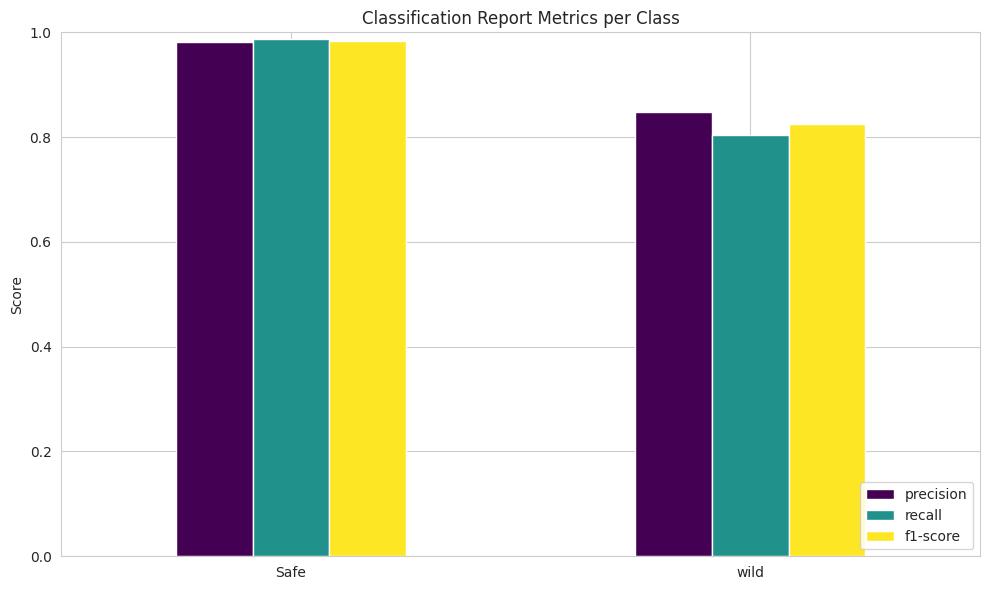

In [44]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd


# -----------------------------------------
# 1. True labels and predicted labels
# -----------------------------------------
y_true = test_gen.classes
y_pred = model_mobilenetV2.predict(test_gen)
y_pred_labels = np.argmax(y_pred, axis=1)

class_names = list(train_gen.class_indices.keys())

# -----------------------------------------
# 2. Generate classification report
# -----------------------------------------
report = classification_report(
    y_true,
    y_pred_labels,
    target_names=class_names,
    output_dict=True  # Add this parameter to get a dictionary output
)

print(classification_report(y_true, y_pred_labels, target_names=class_names)) # Print the readable string version

# -----------------------------------------
# 3. Save classification report
# -----------------------------------------
# Convert to DataFrame
df = pd.DataFrame(report).transpose()

# Keep only class rows (remove accuracy, macro avg, weighted avg)
df_classes = df.iloc[:-3, :][['precision', 'recall', 'f1-score']]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = df_classes.plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title("Classification Report Metrics per Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()

# ---------------------------------------
# 3. Save the figure
# ---------------------------------------
plt.savefig("classification_report_visual.png", dpi=300)

plt.show()


The classification report provides precision, recall, F1‑score, and support for each class (SAFE and WILD).
- Precision measures how many predicted positives were correct,
- recall measures how many actual positives were detected, and
- F1‑score combines both into a single metric.
- Support shows how many samples belong to each class.

Saving this report ensures the evaluation results can be included directly in the final project report

## 9.5 MobileNetV2 Training vs Validation Accuracy Curve

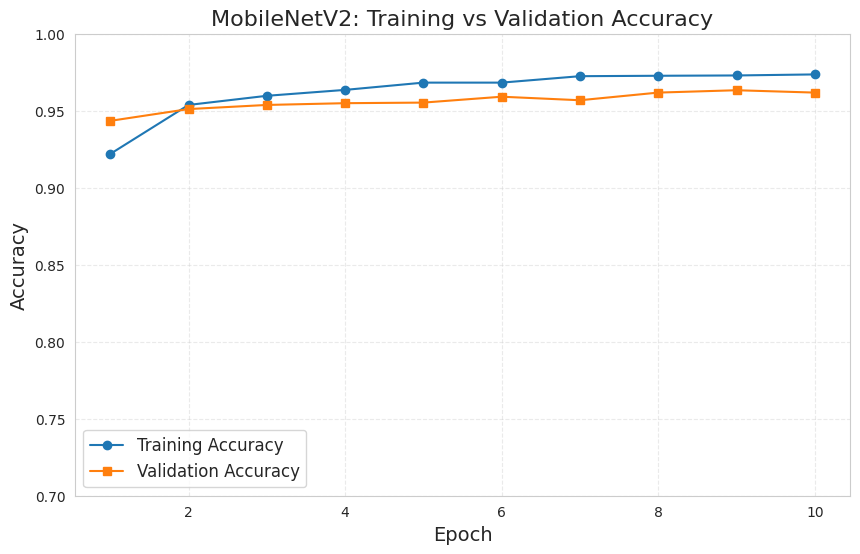

In [45]:
import matplotlib.pyplot as plt

# Extract accuracy values from training history
train_acc = history_mobilenet.history['accuracy']
val_acc = history_mobilenet.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

# Plot the curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_acc, 'o-', label='Training Accuracy', color='#1f77b4')
plt.plot(epochs, val_acc, 's-', label='Validation Accuracy', color='#ff7f0e')

plt.title("MobileNetV2: Training vs Validation Accuracy", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=12)
plt.ylim(0.7, 1.0)

plt.show()

# 9. Real‑World Detection Using the Best Model


In [48]:
!mkdir -p /content/real_world_test

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


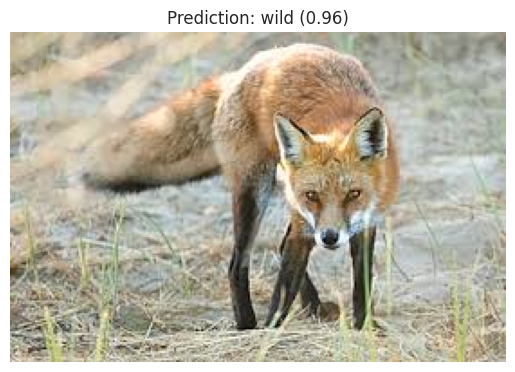

('wild', np.float32(0.96237695))

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ---------------------------------------------------
# Function: Real‑world prediction using best model
# ---------------------------------------------------
def predict_real_image(img_path, model, class_names):
    # Load image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    # Show image + prediction
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f})")
    plt.show()

    return predicted_class, confidence

# ---------------------------------------------------
# Run prediction on any real‑world image
# ---------------------------------------------------
class_names = list(train_gen.class_indices.keys())


img_path = "/content/real_world_test/images.jpg"
predict_real_image(img_path, model_mobilenetV2, class_names)